# Data Pre-Processing

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
base_path = '/content/drive/My Drive/DS 266/Final Project/data/'

# About the Dataset
The dataset used for this project is the [Yelp Open Dataset](https://business.yelp.com/data/resources/open-dataset/). It contains data for 6,990,280 reviews of 150,346 businesses across 11
metropolitan areas. For this project, only 2 files from this dataset will be used: *business.json* and *review.json*, as these contain all data pertaining to restaurants and their text reviews. Due to the size of the dataset, this project will only focus on restaurants located in Philadelphia, PA (the most represented city in the dataset for restaurants).

First, the dataset must be filtered to work with a reasonable number of restaurants. The *business* table contains many businesses that are not restaurants, so these will be filtered out. I will also select one city to work with as an example case for this system. After filtering is applied on the *business* table, the *review* table will be filtered to then include reviews for only the filtered restaurants.

In [3]:
# Helper function to load JSON data into Pandas DataFrame
def load_yelp_data(filepath, num_lines=200000):
    """Load JSON lines format efficiently with optional filtering"""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if num_lines is not None and i >= num_lines:
                break
            record = json.loads(line)

            data.append(record)
    return pd.DataFrame(data)

In [4]:
business_df = load_yelp_data(base_path + 'yelp_academic_dataset_business.json')
print(f"Business shape: {business_df.shape}")
print(business_df.info())

Business shape: (150346, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   150346 non-null  object 
 1   name          150346 non-null  object 
 2   address       150346 non-null  object 
 3   city          150346 non-null  object 
 4   state         150346 non-null  object 
 5   postal_code   150346 non-null  object 
 6   latitude      150346 non-null  float64
 7   longitude     150346 non-null  float64
 8   stars         150346 non-null  float64
 9   review_count  150346 non-null  int64  
 10  is_open       150346 non-null  int64  
 11  attributes    136602 non-null  object 
 12  categories    150243 non-null  object 
 13  hours         127123 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 16.1+ MB
None


In [5]:
# Get all unique categories
all_categories = business_df['categories'].str.split(', ').explode()

# Display the top 20 most frequent categories
display(all_categories.value_counts().head(20))

,count
categories,
Restaurants,52268
Food,27781
Shopping,24395
Home Services,14356
Beauty & Spas,14292
Nightlife,12281
Health & Medical,11890
Local Services,11198
Bars,11065


# Filter to create PHL Restaurants Table

Given that this project is intended for a restuarant recommendation system, we will only include businesses with the "Restaurant" category tag. After some inspection, "Food" businesses that are not restaurants may include grocery stores, convenience stores, and other businesses that are not of interest. Fast Food businesses are also not of interest for this use case, so those will be filtered out.

In [6]:
# Filter for non-fast-food restaurants
restaurants_df = business_df[business_df['categories'].str.contains('Restaurants', na=False)]
restaurants_df = restaurants_df[~restaurants_df['categories'].str.contains('Fast Food', na=False)]
print(restaurants_df.shape)
restaurants_df.head()

(45796, 14)


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,0,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",None
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,1,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'..."
12,il_Ro8jwPlHresjw9EGmBg,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,1,"{'RestaurantsReservations': 'False', 'Restaura...","American (Traditional), Restaurants, Diners, B...","{'Monday': '6:0-22:0', 'Tuesday': '6:0-22:0', ..."
14,0bPLkL0QhhPO5kt1_EXmNQ,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,0,"{'OutdoorSeating': 'False', 'RestaurantsGoodFo...","Food, Delis, Italian, Bakeries, Restaurants","{'Monday': '10:0-18:0', 'Tuesday': '10:0-20:0'..."


In [7]:
# Check the most represented states and cities for restaurants
display(restaurants_df['state'].value_counts().head(10))
display(restaurants_df['city'].value_counts().head(10))

,count
state,
PA,11726
FL,7650
TN,3693
MO,3553
IN,3361
LA,3302
NJ,3031
AZ,2149
AB,2089


,count
city,
Philadelphia,5485
Tampa,2618
Indianapolis,2343
Nashville,2227
New Orleans,2117
Tucson,1997
Edmonton,1879
Saint Louis,1639
Reno,1119


Only restuarants in Philadelphia, PA will be selected as this is the most represented city in the restaurants dataset. Additionally, only restaurants that are open as of 2022 (when the dataset was published) will be included, so as not to provide recommendations for businesses that have shut down.

In [8]:
phl_restaurants_df = restaurants_df[restaurants_df['city'] == 'Philadelphia'][restaurants_df['is_open'] == 1]
print(phl_restaurants_df.shape)
phl_restaurants_df.head()

(3266, 14)


/tmp/ipykernel_26361/92068722.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  phl_restaurants_df = restaurants_df[restaurants_df['city'] == 'Philadelphia'][restaurants_df['is_open'] == 1]


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
15,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,1,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-..."
19,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,1,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","Korean, Restaurants","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20..."
35,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,1,"{'OutdoorSeating': 'True', 'RestaurantsPriceRa...","Eatertainment, Arts & Entertainment, Brewpubs,...","{'Monday': '0:0-0:0', 'Wednesday': '16:0-22:0'..."
82,ppFCk9aQkM338Rgwpl2F5A,Wawa,3604 Chestnut St,Philadelphia,PA,19104,39.954573,-75.194894,3.0,56,1,"{'Alcohol': 'u'none'', 'RestaurantsGoodForGrou...","Restaurants, Automotive, Delis, Gas Stations, ...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W..."


As the semantic retrieval baseline model will rely on embeddings of restaurant reviews, only restaurants with at least 10 reviews will be included in the final dataset.

In [9]:
phl_restaurants_df = phl_restaurants_df[phl_restaurants_df['review_count'] >= 10]
print(phl_restaurants_df.shape)
print(phl_restaurants_df.info())

(2822, 14)
<class 'pandas.core.frame.DataFrame'>
Index: 2822 entries, 3 to 150336
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   business_id   2822 non-null   object 
 1   name          2822 non-null   object 
 2   address       2822 non-null   object 
 3   city          2822 non-null   object 
 4   state         2822 non-null   object 
 5   postal_code   2822 non-null   object 
 6   latitude      2822 non-null   float64
 7   longitude     2822 non-null   float64
 8   stars         2822 non-null   float64
 9   review_count  2822 non-null   int64  
 10  is_open       2822 non-null   int64  
 11  attributes    2814 non-null   object 
 12  categories    2822 non-null   object 
 13  hours         2524 non-null   object 
dtypes: float64(3), int64(2), object(9)
memory usage: 330.7+ KB
None


In [10]:
# Drop rows with null 'attributes' as those values are needed for filtering
phl_restaurants_df = phl_restaurants_df.dropna(subset=['attributes'])
print(phl_restaurants_df.shape)

(2814, 14)


In [11]:
# Clean up columns
phl_restaurants_df = phl_restaurants_df.rename(columns={'stars': 'rating'})
phl_restaurants_df = phl_restaurants_df.drop(columns=['is_open'])

In [12]:
phl_restaurants_df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,rating,review_count,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
15,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-..."
19,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","Korean, Restaurants","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20..."
35,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,"{'OutdoorSeating': 'True', 'RestaurantsPriceRa...","Eatertainment, Arts & Entertainment, Brewpubs,...","{'Monday': '0:0-0:0', 'Wednesday': '16:0-22:0'..."
82,ppFCk9aQkM338Rgwpl2F5A,Wawa,3604 Chestnut St,Philadelphia,PA,19104,39.954573,-75.194894,3.0,56,"{'Alcohol': 'u'none'', 'RestaurantsGoodForGrou...","Restaurants, Automotive, Delis, Gas Stations, ...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W..."


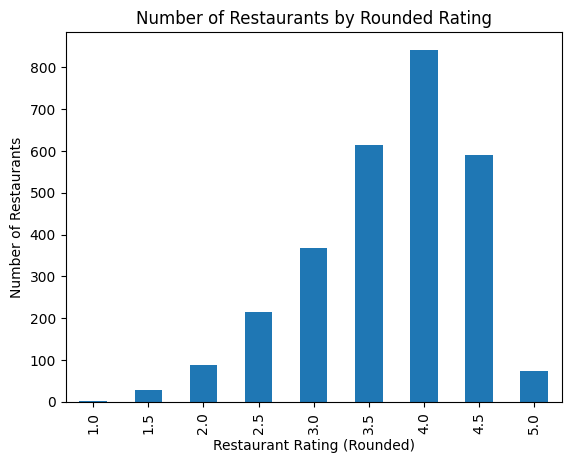

In [14]:
# Plot bar chart of restaurant ratings sorted by rating value
phl_restaurants_df['rating'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Restaurant Rating (Rounded)')
plt.ylabel('Number of Restaurants')
plt.title('Number of Restaurants by Rounded Rating')
plt.show()

The location columns will be used as metadata but not for recommendations in this phase. The last 3 columns (`attributes`, `categories`, `hours`) must be parsed in order to be utilized for SQL logic and semantic retrieval.

The filtered and cleaned dataset will be exported for later use for feature engineering.

In [25]:
# Export to CSV
phl_restaurants_df.to_csv(base_path + 'phl_restaurants_raw.csv', index=False)

# Filter to create PHL Reviews Subset Table

In [16]:
phl_restaurants = set(phl_restaurants_df['business_id'])
print(len(phl_restaurants))

2814


In [17]:
# Load the full reviews dataset with chunking and filtering
review_chunks = []
for chunk in pd.read_json(base_path + 'yelp_academic_dataset_review.json', lines=True, chunksize=100000):
    filtered_chunk = chunk[chunk['business_id'].isin(phl_restaurants)]
    filtered_chunk = filtered_chunk[['review_id','user_id','business_id','stars','text','date']]
    review_chunks.append(filtered_chunk)
    print(f"Chunk shape: {chunk.shape}, Filtered chunk shape: {filtered_chunk.shape}")

Chunk shape: (100000, 9), Filtered chunk shape: (7930, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (8133, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (7985, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (6957, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (5904, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (5480, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (5625, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (9324, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (10119, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (10203, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (9226, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (7821, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (7089, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (7077, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (8058, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (8275, 6)
Chunk shape: (100000, 9), Filtered chunk shape: (8639, 6)
Chunk shape:

In [19]:
phl_reviews_df = pd.concat(review_chunks)
print(f"Reviews shape: {phl_reviews_df.shape}")
phl_reviews_df.head()

Reviews shape: (485743, 6)


,review_id,user_id,business_id,stars,text,date
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
16,oyaMhzBSwfGgemSGuZCdwQ,Dd1jQj7S-BFGqRbApFzCFw,YtSqYv1Q_pOltsVPSx54SA,5,Tremendous service (Big shout out to Douglas) ...,2013-06-24 11:21:25
19,Xs8Z8lmKkosqW5mw_sVAoA,IQsF3Rc6IgCzjVV9DE8KXg,eFvzHawVJofxSnD7TgbZtg,5,My absolute favorite cafe in the city. Their b...,2014-11-12 15:30:27
38,JBWZmBy69VMggxj3eYn17Q,aFa96pz67TwOFu4Weq5Agg,kq5Ghhh14r-eCxlVmlyd8w,5,My boyfriend and I tried this deli for the fir...,2018-08-23 21:39:38
42,YcLXh-3UC9y6YFAI9xxzPQ,G0DHgkSsDozqUPWtlxVEMw,oBhJuukGRqPVvYBfTkhuZA,4,The only reason I didn't give this restaurant ...,2015-03-05 03:37:54


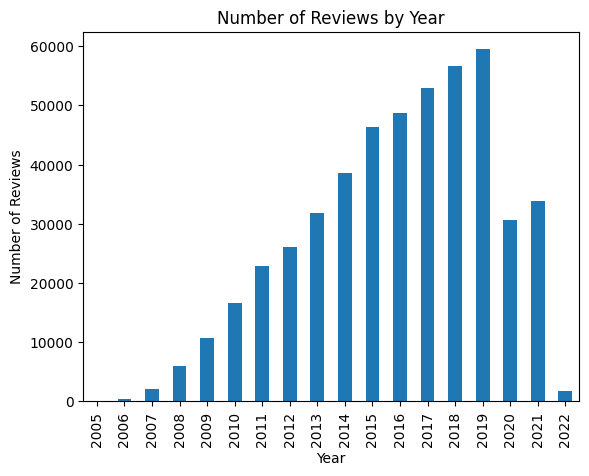

In [21]:
# Plot reviews by year
phl_reviews_df['year'] = pd.to_datetime(phl_reviews_df['date']).dt.year
phl_reviews_df['year'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.title('Number of Reviews by Year')
plt.show()

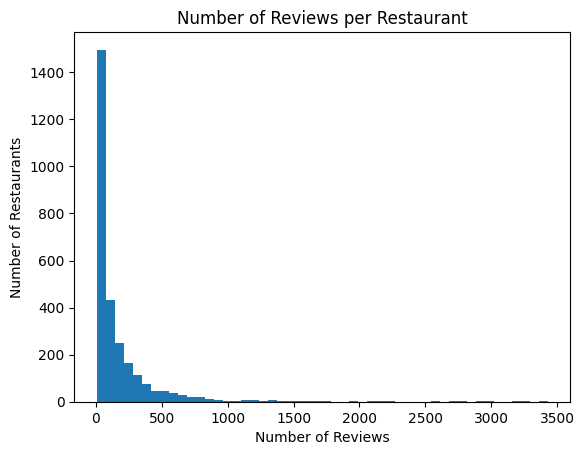

In [23]:
# Plot frequency of reviews per restaurant
phl_reviews_df['business_id'].value_counts().plot(kind='hist', bins=50)
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Restaurants')
plt.title('Number of Reviews per Restaurant')
plt.show()

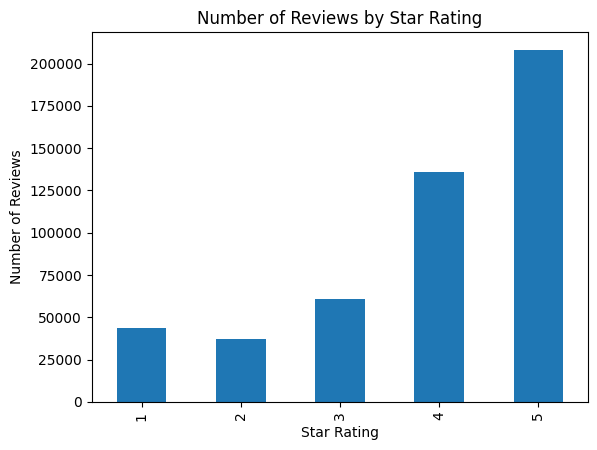

In [24]:
# Plot frequency of reviews by rating given
phl_reviews_df['stars'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.title('Number of Reviews by Star Rating')
plt.show()

In [26]:
phl_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 485743 entries, 3 to 6990260
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   review_id    485743 non-null  object        
 1   user_id      485743 non-null  object        
 2   business_id  485743 non-null  object        
 3   stars        485743 non-null  int64         
 4   text         485743 non-null  object        
 5   date         485743 non-null  datetime64[ns]
 6   year         485743 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(4)
memory usage: 27.8+ MB


,review_id,user_id,business_id,stars,text,date,year
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,2015
16,oyaMhzBSwfGgemSGuZCdwQ,Dd1jQj7S-BFGqRbApFzCFw,YtSqYv1Q_pOltsVPSx54SA,5,Tremendous service (Big shout out to Douglas) ...,2013-06-24 11:21:25,2013
19,Xs8Z8lmKkosqW5mw_sVAoA,IQsF3Rc6IgCzjVV9DE8KXg,eFvzHawVJofxSnD7TgbZtg,5,My absolute favorite cafe in the city. Their b...,2014-11-12 15:30:27,2014
38,JBWZmBy69VMggxj3eYn17Q,aFa96pz67TwOFu4Weq5Agg,kq5Ghhh14r-eCxlVmlyd8w,5,My boyfriend and I tried this deli for the fir...,2018-08-23 21:39:38,2018
42,YcLXh-3UC9y6YFAI9xxzPQ,G0DHgkSsDozqUPWtlxVEMw,oBhJuukGRqPVvYBfTkhuZA,4,The only reason I didn't give this restaurant ...,2015-03-05 03:37:54,2015


In [28]:
# Drop user_id column as not applicable for this project
phl_reviews_df = phl_reviews_df.drop(columns=['user_id'])
phl_reviews_df.head()

,review_id,business_id,stars,text,date,year
3,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,5,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,2015
16,oyaMhzBSwfGgemSGuZCdwQ,YtSqYv1Q_pOltsVPSx54SA,5,Tremendous service (Big shout out to Douglas) ...,2013-06-24 11:21:25,2013
19,Xs8Z8lmKkosqW5mw_sVAoA,eFvzHawVJofxSnD7TgbZtg,5,My absolute favorite cafe in the city. Their b...,2014-11-12 15:30:27,2014
38,JBWZmBy69VMggxj3eYn17Q,kq5Ghhh14r-eCxlVmlyd8w,5,My boyfriend and I tried this deli for the fir...,2018-08-23 21:39:38,2018
42,YcLXh-3UC9y6YFAI9xxzPQ,oBhJuukGRqPVvYBfTkhuZA,4,The only reason I didn't give this restaurant ...,2015-03-05 03:37:54,2015


In [29]:
# Export to csv
phl_reviews_df.to_csv(base_path + 'phl_reviews.csv', index=False)